In [1]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Literal
from langchain_huggingface import HuggingFacePipeline , ChatHuggingFace ,HuggingFaceEndpoint
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel,Field
from langchain_core.prompts import PromptTemplate

e:\langgarph\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# LOCAL_MODEL_PATH = r"C:\Users\dell\.cache\huggingface\hub\models--TinyLlama--TinyLlama-1.1B-Chat-v1.0\snapshots\fe8a4ea1ffedaf415f4da2f062534de366a451e6"

# tokenizer = AutoTokenizer.from_pretrained(LOCAL_MODEL_PATH)

# hf_model = AutoModelForCausalLM.from_pretrained(
#     LOCAL_MODEL_PATH,
#     torch_dtype="auto"
# )

# # 3. Important: return_full_text=False
# pipe = pipeline(
#     "text-generation",
#     model=hf_model,
#     tokenizer=tokenizer,
#     max_new_tokens=30,
#     do_sample=False,
#     temperature=0.0,
#     return_full_text=False,
# )

# llm = HuggingFacePipeline(pipeline=pipe)
# chat_model = ChatHuggingFace(llm=llm)

In [3]:
llm = HuggingFaceEndpoint(
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="text-generation")

model = ChatHuggingFace(llm=llm)

In [4]:
class Sentiment_schema(BaseModel):
    sentiment : Literal["positive","negative"] = Field(description="Sentiment of the review")

In [21]:
parser_sentiment = PydanticOutputParser(pydantic_object=Sentiment_schema)

In [ ]:
prompt_sentiment = PromptTemplate(
    template="""
you are sentiment classifier .
return ONLY valide JSON
{format_instrucations}
Review:{review}""",
input_variables=["review"],
partial_variables={"format_instrucations":parser_sentiment.get_format_instructions()}
)

In [23]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [24]:
parser_dignosis = PydanticOutputParser(pydantic_object=DiagnosisSchema)

In [40]:
prompt_dignosis = PromptTemplate(
    template="""
you are sentiment classifier .
return ONLY valide JSON
{format_instrucations}
Review:{review}""",
input_variables=["review"],
partial_variables={"format_instrucations":parser_dignosis.get_format_instructions()}
)

In [41]:
class Parallel_state(TypedDict):
    review : str
    sentiment : Literal["positive","negative"]
    diagnose : dict
    responce : str

In [42]:
def check_sentiment(state:Parallel_state):
    review = state["review"]
    chain_sentiment = prompt_sentiment | model | parser_sentiment
    sentiment = chain_sentiment.invoke({"review":review})
    state["sentiment"] = sentiment

    return state 

In [43]:
def check_dignose(state:Parallel_state):
    review = state["review"]
    chain_dignose = prompt_dignosis | model | parser_dignosis
    diagnose = chain_dignose.invoke({"review":review})
    state["diagnose"] = diagnose

    return state

In [44]:
def negative_responce(state:Parallel_state):
    review = state["review"]
    dignose = state["diagnose"]
    prompt = f"create sorry responce of {review} on the besis of promble {dignose}"
    responce = model.invoke(prompt)
    state["responce"] = responce
    return state

In [45]:
def postive_responce(state:Parallel_state):
    review = state["review"]
    prompt = f"create positive responce of {review}"
    responce = model.invoke(prompt)
    state["responce"] = responce
    return state


In [46]:
def choose_responce(state:Parallel_state) -> Literal ["postive_responce","check_dignose"]:
    if state["sentiment"] == "positive":
        return "postive_responce"
    else:
        return "check_dignose"

In [47]:
graph = StateGraph(Parallel_state)

graph.add_node("check_sentiment",check_sentiment)
graph.add_node("check_dignose",check_dignose)
graph.add_node("negative_responce",negative_responce)
graph.add_node("postive_responce",postive_responce)

graph.add_edge(START,"check_sentiment")
graph.add_conditional_edges("check_sentiment",choose_responce)
graph.add_edge("postive_responce",END)
graph.add_edge("check_dignose","negative_responce")
graph.add_edge("negative_responce",END)

workflow = graph.compile()

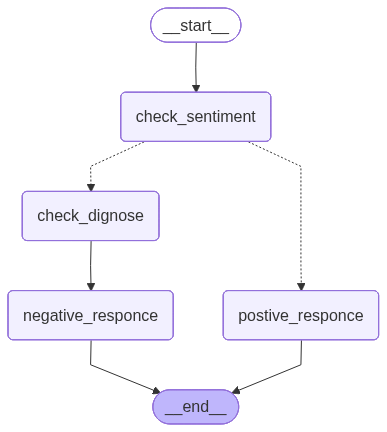

In [48]:
workflow

In [49]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
final_state = workflow.invoke(intial_state)

In [50]:
final_state

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': Sentiment_schema(sentiment='negative'),
 'diagnose': DiagnosisSchema(issue_type='Bug', tone='frustrated', urgency='high'),
 'responce': AIMessage(content=" Dear Valued User,\n\nI am truly sorry for the inconvenience you've experienced while trying to log into the app. I understand that you have been attempting to access the app for over an hour, but have been met with a frozen authentication screen. This is not the experience we strive to provide for our users.\n\nI empathize with your frustration and share your disappointment in the current situation. I assure you that we take issues like this seriously and understand the impact it has on your ability to use our services.\n\nI suggest trying the following steps to troubleshoot the

In [51]:
intial_state={
    'review': "this is very good mobile i like it very well"
}
final_state = workflow.invoke(intial_state)

In [53]:
final_state

{'review': 'this is very good mobile i like it very well',
 'sentiment': Sentiment_schema(sentiment='positive'),
 'diagnose': DiagnosisSchema(issue_type='Other', tone='calm', urgency='low'),
 'responce': AIMessage(content=" I'm glad you find the mobile version of this application good and enjoy using it. Regarding the problem you mentioned, I'm sorry for any inconvenience caused, and I'll do my best to help you with it. However, I'll need some more information to identify and resolve the issue. Could you please provide some details about the issue you're experiencing? What specifically is not working, and when did it start happening? Thank you for bringing this to my attention, and I appreciate your patience as we work to make things right.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 114, 'prompt_tokens': 46, 'total_tokens': 160}, 'model_name': 'mistralai/Mistral-7B-Instruct-v0.2', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None},